## TASK 2

In [1]:
%pip install autogluon

In [9]:
import pandas as pd
import autogluon.common as ag
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# =============================================================================
# Data Preparation
# =============================================================================
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Split the data into training, validation, and test sets
train_val, val_set = train_test_split(df, test_size=0.1, stratify=df['target'], random_state=42)
train_set, test_set = train_test_split(train_val, test_size=0.2 / 0.9, stratify=train_val['target'], random_state=42)

# Convert DataFrames into AutoGluon TabularDataset format
train_data = TabularDataset(train_set)
val_data   = TabularDataset(val_set)
test_data  = TabularDataset(test_set)
true_labels = test_data['target']

# =============================================================================
# Model Building and Evaluation Functions
# =============================================================================
def build_predictor(search_method: str) -> TabularPredictor:
    """
    Constructs and fits a TabularPredictor using hyperparameter tuning.

    Parameters:
        search_method (str): The search strategy for hyperparameter tuning (e.g. 'random' or 'bayes').

    Returns:
        A fitted TabularPredictor.
    """
    predictor = TabularPredictor(label='target', problem_type='multiclass', eval_metric='accuracy')
    return predictor.fit(
        train_data=train_data,
        tuning_data=val_data,
        hyperparameters={
            'NN_TORCH': {
                'batch_size': ag.space.Categorical(2, 4),
                'num_epochs': ag.space.Categorical(1, 3, 5),
                'learning_rate': ag.space.Categorical(1e-3, 1e-5),
                'num_layers': 1,
                'hidden_size': 16,
                'activation': 'relu'
            }
        },
        hyperparameter_tune_kwargs={
            'num_trials': 10,
            'scheduler': 'local',
            'searcher': search_method
        },
        num_bag_folds=5,
        num_stack_levels=0,
        use_bag_holdout=True,
        time_limit=100
    )

def evaluate_model(predictor: TabularPredictor, dataset: TabularDataset, description: str):
    """
    Evaluates the predictor on the given dataset and prints performance metrics and leaderboard.

    Parameters:
        predictor (TabularPredictor): The trained model.
        dataset (TabularDataset): The test data.
        description (str): Description of the search strategy.
    """
    predictions = predictor.predict(dataset.drop(columns=['target']))
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='weighted')

    print(description)
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    lb = predictor.leaderboard(dataset)
    print("Leaderboard:")
    print(lb[['model', 'score_test', 'fit_time']])

    return acc, f1, lb

# =============================================================================
# Analysis and Discussion
# =============================================================================
# Hyperparameter Impact:
#   - Epochs: Increasing epochs generally enhances performance by allowing more learning iterations.
#   - Batch Size: Smaller batch sizes may improve performance due to more frequent updates.
#   - Learning Rate: A higher learning rate can accelerate convergence, reducing loss more quickly.
#
# Automated Search vs. Manual Tuning:
#   Automated hyperparameter optimization systematically explores a wide range of configurations,
#   often yielding superior performance compared to manual tuning. While manual tuning can leverage
#   domain expertise, it is generally more time-consuming and less comprehensive.


In [11]:

# =============================================================================
# Build and Evaluate Predictors using Different Search Strategies
# =============================================================================
# Random Search
random_pred = build_predictor('random')
acc_random, f1_random, lb_random = evaluate_model(random_pred, test_data, "Random Search:")



No path specified. Models will be saved in: "AutogluonModels/ag-20250226_190303"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       10.19 GB / 12.67 GB (80.4%)
Disk Space Avail:   71.15 GB / 107.72 GB (66.1%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions 

+----------------------------------------------------------+
| Configuration for experiment     NeuralNetTorch_BAG_L1   |
+----------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator   |
| Scheduler                        FIFOScheduler           |
| Number of trials                 10                      |
+----------------------------------------------------------+

View detailed results here: /content/AutogluonModels/ag-20250226_190303/models/NeuralNetTorch_BAG_L1


Fitted model: NeuralNetTorch_BAG_L1/4de56_00000 ...
	0.4904	 = Validation score   (accuracy)
	21.96s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: NeuralNetTorch_BAG_L1/4de56_00001 ...
	0.6731	 = Validation score   (accuracy)
	21.33s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: NeuralNetTorch_BAG_L1/4de56_00002 ...
	0.6346	 = Validation score   (accuracy)
	23.7s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 99.95s of the 9.61s of remaining time.
	Ensemble Weights: {'NeuralNetTorch_BAG_L1/4de56_00001': 1.0}
	0.6667	 = Validation score   (accuracy)
	0.0s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 90.42s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 740.3 rows/s (15 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/AutogluonModels/ag-20250226_190303")
2025-02-26 19


Random Search:
Test Accuracy: 0.6452
Test F1 Score: 0.5451
Leaderboard:
                               model  score_test   fit_time
0  NeuralNetTorch_BAG_L1/4de56_00001    0.645161  21.333567
1                WeightedEnsemble_L2    0.645161  21.337453
2  NeuralNetTorch_BAG_L1/4de56_00002    0.612903  23.701852
3  NeuralNetTorch_BAG_L1/4de56_00000    0.354839  21.958367


In [12]:
# Hyperband Search with Bayesian Optimization
bayes_pred = build_predictor('bayes')
acc_bayes, f1_bayes, lb_bayes = evaluate_model(bayes_pred, test_data, "Hyperband Search + Bayes Optimization:")

No path specified. Models will be saved in: "AutogluonModels/ag-20250226_190433"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       9.81 GB / 12.67 GB (77.4%)
Disk Space Avail:   71.15 GB / 107.72 GB (66.1%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions a

+----------------------------------------------------------+
| Configuration for experiment     NeuralNetTorch_BAG_L1   |
+----------------------------------------------------------+
| Search algorithm                 SearchGenerator         |
| Scheduler                        FIFOScheduler           |
| Number of trials                 10                      |
+----------------------------------------------------------+

View detailed results here: /content/AutogluonModels/ag-20250226_190433/models/NeuralNetTorch_BAG_L1


Fitted model: NeuralNetTorch_BAG_L1/869d9261 ...
	0.4904	 = Validation score   (accuracy)
	20.87s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: NeuralNetTorch_BAG_L1/70637083 ...
	0.1346	 = Validation score   (accuracy)
	21.45s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: NeuralNetTorch_BAG_L1/d273a16d ...
	0.625	 = Validation score   (accuracy)
	21.0s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 99.93s of the 9.56s of remaining time.
	Ensemble Weights: {'NeuralNetTorch_BAG_L1/d273a16d': 1.0}
	0.5333	 = Validation score   (accuracy)
	0.0s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 90.47s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 703.9 rows/s (15 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/AutogluonModels/ag-20250226_190433")



Hyperband Search + Bayes Optimization:
Test Accuracy: 0.6129
Test F1 Score: 0.5192
Leaderboard:
                            model  score_test   fit_time
0  NeuralNetTorch_BAG_L1/d273a16d    0.612903  20.996867
1             WeightedEnsemble_L2    0.612903  21.000412
2  NeuralNetTorch_BAG_L1/869d9261    0.354839  20.872975
3  NeuralNetTorch_BAG_L1/70637083    0.032258  21.450778


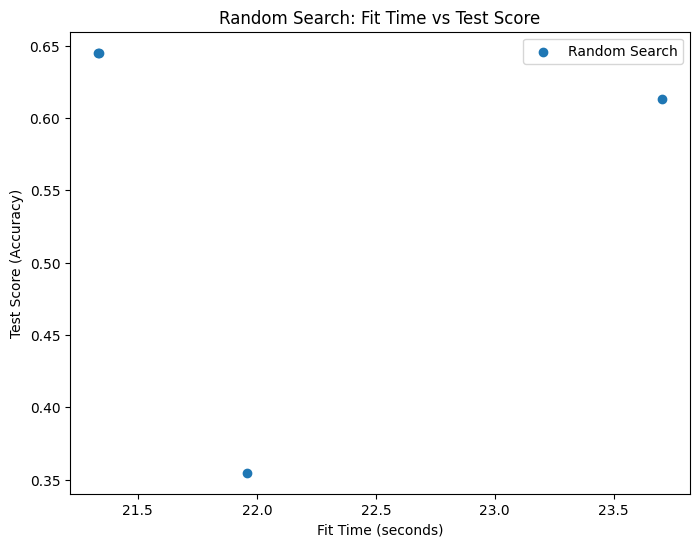

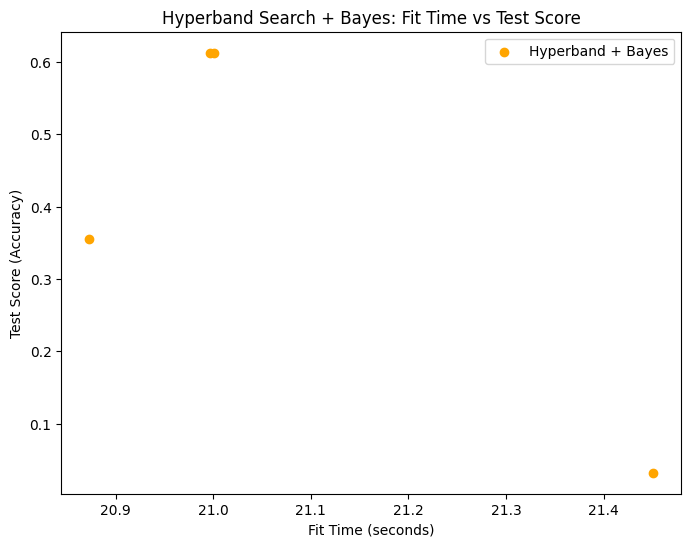

Summary of AutoGluon Search Results:
       Search Method  Accuracy  F1 Score
0      Random Search  0.645161  0.545050
1  Hyperband + Bayes  0.612903  0.519201


In [13]:


# =============================================================================
# Plotting Evaluation Metrics from the Leaderboard
# =============================================================================
# Scatter Plot: Fit Time vs. Test Score for Random Search
plt.figure(figsize=(8, 6))
plt.scatter(lb_random['fit_time'], lb_random['score_test'], label='Random Search', marker='o')
plt.xlabel('Fit Time (seconds)')
plt.ylabel('Test Score (Accuracy)')
plt.title('Random Search: Fit Time vs Test Score')
plt.legend()
plt.show()

# Scatter Plot: Fit Time vs. Test Score for Hyperband + Bayes Search
plt.figure(figsize=(8, 6))
plt.scatter(lb_bayes['fit_time'], lb_bayes['score_test'], label='Hyperband + Bayes', marker='o', color='orange')
plt.xlabel('Fit Time (seconds)')
plt.ylabel('Test Score (Accuracy)')
plt.title('Hyperband Search + Bayes: Fit Time vs Test Score')
plt.legend()
plt.show()

# =============================================================================
# Summary Table: Comparing Performance of Different Search Methods
# =============================================================================
summary_df = pd.DataFrame({
    'Search Method': ['Random Search', 'Hyperband + Bayes'],
    'Accuracy': [acc_random, acc_bayes],
    'F1 Score': [f1_random, f1_bayes]
})
print("Summary of AutoGluon Search Results:")
print(summary_df)


# Impact of Hyperparameters on Model Performance

**Epochs**:
Increasing the number of epochs generally improves model performance because it allows the model more iterations to learn from the data. This trend is visible in the loss-versus-epochs plots, where a higher epoch count corresponds with lower loss values, indicating better learning.

**Batch Size**:
A smaller batch size tends to enhance performance, as it leads to more frequent weight updates during training. In contrast, larger batch sizes may result in higher loss values, suggesting that the model might be less responsive to subtle patterns in the data.

**Learning Rate:**
A higher learning rate can help the model converge faster, often resulting in lower loss values. This relationship is observed across different hyperparameter settings, where increasing the learning rate generally correlates with improved performance.

# Manual Tuning vs. Automated Search
**Automated Search:**
Automated hyperparameter tuning is particularly advantageous for large, complex models. It efficiently explores a broad range of parameter combinations, often achieving superior results while reducing the time and effort required compared to manual tuning.

**Manual Tuning**:
Manual tuning can be beneficial when you possess strong domain knowledge and intuition about the problem. It may be a more practical option for smaller models or when computational resources are limited, even though it might not explore the parameter space as thoroughly as automated methods.